In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [29]:
# Problem 3.1
# Black-Scholes delta function for a European call option
def call_option_delta(S, K, r, sigma, q, T):
    """
    S = initial stock price
    K = strike price
    r = risk-free rate
    sigma = volitility
    q = dividend yield
    T = time to expiry (in years)
    """
    # N(d1) is the factor by which the discounted expected value of contingent receipt of the stock exceeds the current value of the stock.
    # In simple terms if the option is in the money, d1 tells how far into the money it is
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    delta = norm.cdf(d1)

    return delta

In [30]:
# Set parameters
K = 100
r = 0.05
sigma = 0.2
q = 0.02
T = 1

In [31]:
# Create list for stock prices and deltas
S_prices = [i*K / 100 for i in range(1,201)]

deltas = [call_option_delta(S,K,r,sigma,q,T) for S in S_prices]

In [32]:
# Convert to a pandas dataframe
df = pd.DataFrame({
    'Stock Price (S)': S_prices,
    'Delta': deltas
})

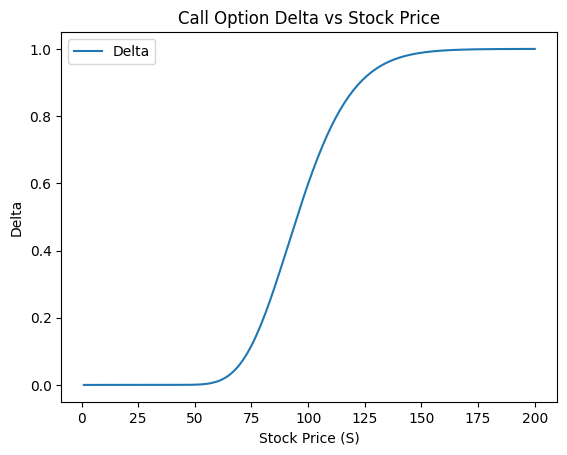

In [33]:
# Plot delta vs stock price
df.plot(x='Stock Price (S)', y='Delta', title='Call Option Delta vs Stock Price')
plt.xlabel("Stock Price (S)")
plt.ylabel("Delta")
plt.show()

In [34]:
# Problem 3.3
# Repeating for the gamma of a call option
def call_option_gamma(S, K, r, sigma, q, T):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    nd1 = np.exp(-d1 * d1 / 2) / np.sqrt(2 * np.pi)
    gamma = np.exp(-q*T) * nd1 / (S * sigma * np.sqrt(T))
    
    return gamma

In [35]:
gammas = [call_option_gamma(S,K,r,sigma,q,T) for S in S_prices]

df['Gamma'] = gammas

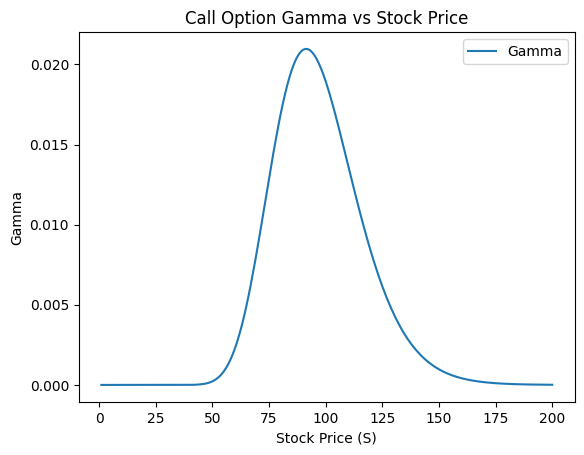

In [36]:
# Plot gamma vs stock price
df.plot(x='Stock Price (S)', y='Gamma', title='Call Option Gamma vs Stock Price')
plt.xlabel("Stock Price (S)")
plt.ylabel("Gamma")
plt.show()

In [37]:
# Problem 3.7
# Black-Scholes call option pricing function
def black_scholes_call(S, K, r, sigma, q, T):
    if sigma == 0:
        black_scholes_price = max(0, np.exp(-q*T)*S - np.exp(-r*T)*K)
    else:
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        N1 = norm.cdf(d1)
        N2 = norm.cdf(d2)
        black_scholes_price = np.exp(-q*T)*S*N1 - np.exp(-r*T)*K*N2

    return black_scholes_price

In [38]:
# Set S = K for this problem
S_37 = K

# Volatility range
volatilities = np.arange(0.01, 1.01, 0.01)

# Compute call option values for each volatility
call_values = [black_scholes_call(S_37, K, r, sigma, q, T) for sigma in volatilities]

In [40]:
df_vols = pd.DataFrame({
    'Volatility': volatilities,
    'Call Option Value': call_values
})

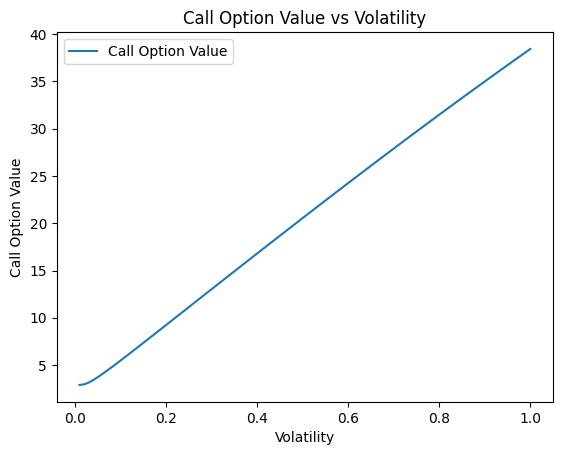

In [42]:
# Plot call value vs volatility
df_vols.plot(x='Volatility', y='Call Option Value', title='Call Option Value vs Volatility')
plt.xlabel("Volatility")
plt.ylabel("Call Option Value")
plt.show()

In [46]:
# Problem 3.8
# Changing S to 1.2K
S_38 = 1.2 * K

# Compute call option values for each volatility
new_call_values = [black_scholes_call(S_38, K, r, sigma, q, T) for sigma in volatilities]
df_vols['Call Option Value (1.2*K)'] = new_call_values

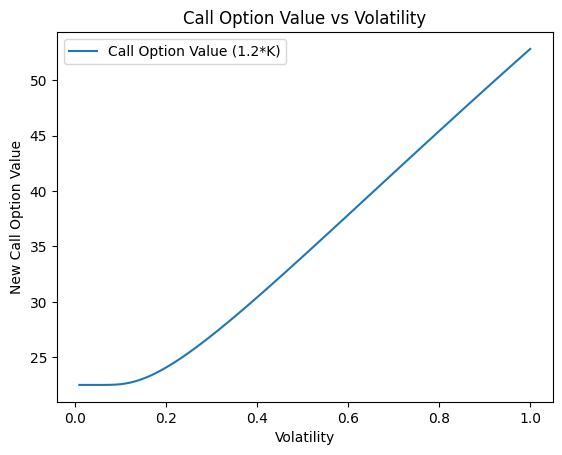

In [48]:
# Plot call value vs volatility
df_vols.plot(x='Volatility', y='Call Option Value (1.2*K)', title='Call Option Value vs Volatility')
plt.xlabel("Volatility")
plt.ylabel("New Call Option Value")
plt.show()